# Team 1 – AI-Enhanced Network Anomaly Detection

## Phase 1: CIC-IDS2017 Data Exploration

### Purpose

This notebook performs an initial exploration of the CIC-IDS2017
network intrusion detection dataset before machine-learning model
development.

The objectives of this phase are to:

- examine the available network features and labels;
- identify normal and malicious traffic classes;
- identify missing, duplicate, or invalid data;
- examine class distribution;
- document preprocessing requirements; and
- prepare the dataset for the traditional machine-learning baseline.

The next development phase will compare Decision Tree and Random
Forest classifiers using a controlled training and holdout approach.

## Dataset

**Dataset:** CIC-IDS2017  
**Source:** Canadian Institute for Cybersecurity (CIC), University of New Brunswick

CIC-IDS2017 contains labeled network traffic representing benign
activity and multiple types of simulated attacks.

For the initial proof of concept, a selected CIC-IDS2017 flow CSV
will be used to develop and verify the data-processing pipeline.

The specific source file and attack scenario used in this experiment
will be documented below before model training begins.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_FILE = Path("../data/raw/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

if not DATA_FILE.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_FILE}")

print(f"Using dataset: {DATA_FILE.name}")

Using dataset: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [2]:
df = pd.read_csv(DATA_FILE, low_memory=False)

# Remove accidental leading/trailing spaces from column names
df.columns = df.columns.str.strip()

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 225,745
Columns: 79


In [3]:
display(df.head())

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
print("Traffic labels:")
display(df["Label"].value_counts())

Traffic labels:


Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

In [5]:
print(f"Total records: {len(df):,}")
print(f"Duplicate records: {df.duplicated().sum():,}")
print(f"Missing values: {df.isna().sum().sum():,}")

# Show columns containing missing values
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("No missing values detected.")
else:
    print("\nColumns containing missing values:")
    display(missing)

Total records: 225,745
Duplicate records: 2,633
Missing values: 4

Columns containing missing values:


Flow Bytes/s    4
dtype: int64

In [6]:
numeric_df = df.select_dtypes(include=np.number)

infinite_count = np.isinf(numeric_df.to_numpy()).sum()

print(f"Numeric features: {numeric_df.shape[1]}")
print(f"Infinite numeric values: {infinite_count:,}")

Numeric features: 78
Infinite numeric values: 64


In [7]:
print(f"Number of columns: {len(df.columns)}")
print("\nDataset columns:")

for number, column in enumerate(df.columns, start=1):
    print(f"{number:>2}. {column}")

Number of columns: 79

Dataset columns:
 1. Destination Port
 2. Flow Duration
 3. Total Fwd Packets
 4. Total Backward Packets
 5. Total Length of Fwd Packets
 6. Total Length of Bwd Packets
 7. Fwd Packet Length Max
 8. Fwd Packet Length Min
 9. Fwd Packet Length Mean
10. Fwd Packet Length Std
11. Bwd Packet Length Max
12. Bwd Packet Length Min
13. Bwd Packet Length Mean
14. Bwd Packet Length Std
15. Flow Bytes/s
16. Flow Packets/s
17. Flow IAT Mean
18. Flow IAT Std
19. Flow IAT Max
20. Flow IAT Min
21. Fwd IAT Total
22. Fwd IAT Mean
23. Fwd IAT Std
24. Fwd IAT Max
25. Fwd IAT Min
26. Bwd IAT Total
27. Bwd IAT Mean
28. Bwd IAT Std
29. Bwd IAT Max
30. Bwd IAT Min
31. Fwd PSH Flags
32. Bwd PSH Flags
33. Fwd URG Flags
34. Bwd URG Flags
35. Fwd Header Length
36. Bwd Header Length
37. Fwd Packets/s
38. Bwd Packets/s
39. Min Packet Length
40. Max Packet Length
41. Packet Length Mean
42. Packet Length Std
43. Packet Length Variance
44. FIN Flag Count
45. SYN Flag Count
46. RST Flag Count
47

In [8]:
print(f"Total records: {len(df):,}")
print(f"Duplicate records: {df.duplicated().sum():,}")
print(f"Missing values: {df.isna().sum().sum():,}")

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("No missing values detected.")
else:
    print("\nColumns containing missing values:")
    display(missing)

Total records: 225,745
Duplicate records: 2,633
Missing values: 4

Columns containing missing values:


Flow Bytes/s    4
dtype: int64

In [9]:
infinite_by_column = pd.Series(
    np.isinf(numeric_df).sum(),
    index=numeric_df.columns
)

infinite_by_column = infinite_by_column[infinite_by_column > 0]

print("Columns containing infinite values:")
display(infinite_by_column)

Columns containing infinite values:


Flow Bytes/s      30
Flow Packets/s    34
dtype: int64

In [10]:
header_columns_match = df["Fwd Header Length"].equals(
    df["Fwd Header Length.1"]
)

print(
    "Are 'Fwd Header Length' and "
    "'Fwd Header Length.1' identical?",
    header_columns_match
)

Are 'Fwd Header Length' and 'Fwd Header Length.1' identical? True


In [11]:
duplicate_rows = df[df.duplicated(keep=False)]

print("Labels among duplicated records:")
display(duplicate_rows["Label"].value_counts())

Labels among duplicated records:


Label
BENIGN    3920
DDoS        20
Name: count, dtype: int64

## Initial Data Quality Findings

The initial assessment of the CIC-IDS2017 Friday Afternoon DDoS
dataset identified the following characteristics:

- **Total records:** 225,745
- **Total columns:** 79
- **Numeric features:** 78
- **DDoS records:** 128,027
- **BENIGN records:** 97,718
- **Duplicate records:** 2,633 duplicate occurrences beyond their first occurrence
- **Missing values:** 4
- **Missing-value feature:** Flow Bytes/s
- **Infinite values:** 64
  - Flow Bytes/s: 30
  - Flow Packets/s: 34
- **Duplicate feature:** Fwd Header Length.1 is identical to Fwd Header Length

The duplicate-record investigation showed that duplicated groups are
primarily associated with BENIGN traffic. Because removing duplicate
records can change the class distribution, duplicate handling will be
performed explicitly during preprocessing rather than silently during
initial exploration.

The missing and infinite values must also be handled before model
training because machine-learning estimators require valid finite
numeric input.

The original raw dataset will remain unchanged. All preprocessing will
be performed on a separate working copy.

Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


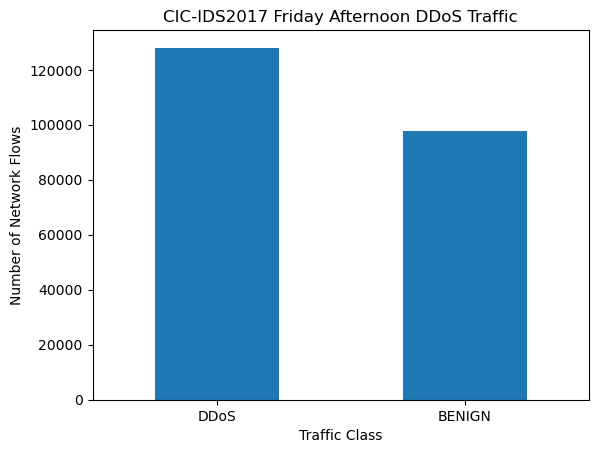

In [12]:
class_counts = df["Label"].value_counts()

print(class_counts)

class_counts.plot(kind="bar")

plt.title("CIC-IDS2017 Friday Afternoon DDoS Traffic")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Network Flows")
plt.xticks(rotation=0)
plt.show()